Elongation experiment.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from vertax import BilevelOptimizationMethod, BoundedBilevelOptimizer, BoundedMesh, plot_mesh
from vertax.cost import cost_ratio
from vertax.energy import energy_bounded


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


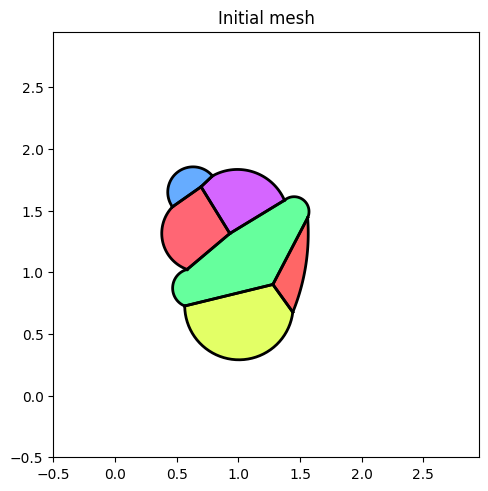

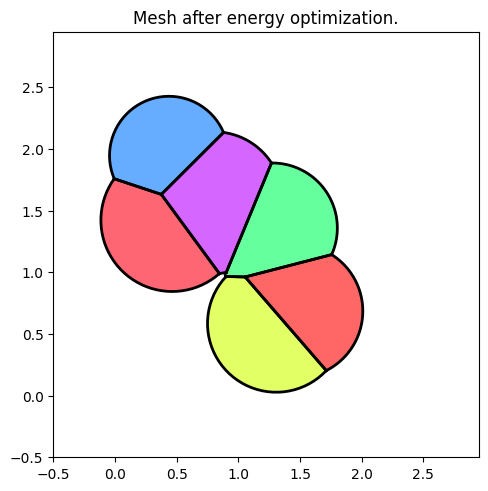

epoch: 0/10000, current cost is 0.1940184235572815


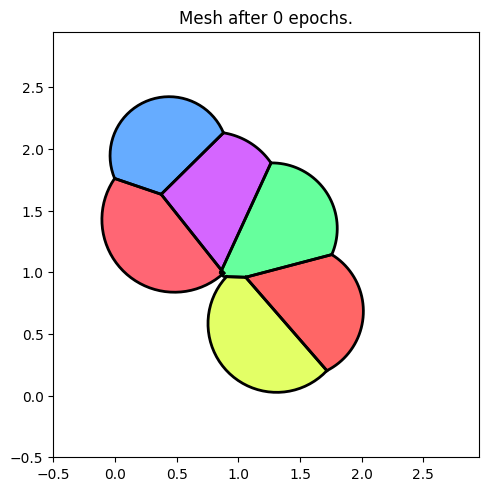

epoch: 1/10000, current cost is 0.21012860536575317
epoch: 2/10000, current cost is 0.23452237248420715
epoch: 3/10000, current cost is 0.22601035237312317
epoch: 4/10000, current cost is 0.2632492482662201
epoch: 5/10000, current cost is 0.2282690405845642
epoch: 6/10000, current cost is 0.16527587175369263
epoch: 7/10000, current cost is 0.12142550945281982
epoch: 8/10000, current cost is 0.08671290427446365
epoch: 9/10000, current cost is 0.07021798193454742
epoch: 10/10000, current cost is 0.06637032330036163
epoch: 11/10000, current cost is 0.060619059950113297
epoch: 12/10000, current cost is 0.05899433791637421
epoch: 13/10000, current cost is 0.05722422152757645
epoch: 14/10000, current cost is 0.05634542927145958
epoch: 15/10000, current cost is 0.05272664874792099
epoch: 16/10000, current cost is 0.028966210782527924
epoch: 17/10000, current cost is 0.012138192541897297
epoch: 18/10000, current cost is 0.0022715998347848654
epoch: 19/10000, current cost is 0.00023116018564905

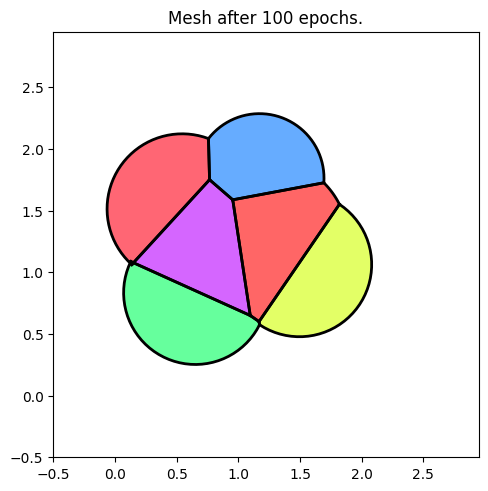

epoch: 101/10000, current cost is 0.7729414701461792
epoch: 102/10000, current cost is 0.7709971070289612
epoch: 103/10000, current cost is 0.7690499424934387
epoch: 104/10000, current cost is 0.7670993804931641
epoch: 105/10000, current cost is 0.765142560005188


KeyboardInterrupt: 

In [ ]:
"""Initial configuration is created randomly."""
"""Change n_cells and target_ratio to emulate the battery of tests found in the paper."""

# Set mesh geometry
n_cells = 6
L_box = jnp.sqrt(n_cells)
width = float(L_box)
height = float(L_box)

# Create a new mesh
rng = np.random.default_rng(1337)
rng_seed = rng.integers(0, 2 ** 32 - 1)
mesh = BoundedMesh.from_random_seeds(nb_seeds=n_cells, width=width, height=height, random_key=rng_seed)
plot_mesh(mesh, title="Initial mesh")

# Initialize degrees of freedom
mesh.vertices_params = jnp.asarray([0.0 for _ in range(mesh.nb_vertices)])
key = jax.random.PRNGKey(rng_seed)
mesh.edges_params = jax.random.uniform(key, (mesh.nb_edges,))* 20 - 10
mesh.faces_params = jnp.asarray([0.0 for _ in range(mesh.nb_faces)])

# Set inner optimization hyperparameters
bilevel_optimizer = BoundedBilevelOptimizer()
bilevel_optimizer.inner_solver = optax.sgd(learning_rate=0.01)
bilevel_optimizer.update_T1 = True
bilevel_optimizer.min_dist_T1 = 0.025
bilevel_optimizer.max_nb_iterations = 1000
bilevel_optimizer.tolerance = 1e-6
bilevel_optimizer.patience = 5

# Perform energy optimization
bilevel_optimizer.loss_function_inner=energy_bounded
loss_history = bilevel_optimizer.inner_optimization(mesh)
plot_mesh(mesh, title="Mesh after energy optimization.")

# Set outer optimization hyperparameters
bilevel_optimizer.outer_solver = optax.adam(learning_rate=0.01, nesterov=True)
bilevel_optimizer.bilevel_optimization_method = BilevelOptimizationMethod.AUTOMATIC_DIFFERENTIATION
epochs = 10000
target_ratio = 2.0
bilevel_optimizer.loss_function_outer = cost_ratio

# Perform bilevel optimization
for epoch in range(epochs + 1):
    cost = cost_ratio(mesh.vertices)
    print(f"epoch: {epoch}/{epochs}, current cost is {cost}")
    loss_history = bilevel_optimizer.bilevel_optimization(mesh)
    if epoch % 100 == 0:
        plot_mesh(mesh, title=f"Mesh after {epoch} epochs.")